In [4]:
import os
import sys
sys.path.append("../..")

import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.distributions as td
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.datasets import TUDataset

from egg_models import egg_generic_losses
from egg_models.egg_generic import EggGeneric
from egg_models.egg_generic import EggGeneric
from functools import partial
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t
from sklearn.metrics import confusion_matrix

from utils import mutag_helper
from utils import visuals
import pygmtools as pygm
import networkx as nx

from egg_models.egg_generic_losses import activation_hook, dict_cos_dist, GEDasMatchLoss
from scipy.stats import stats

In [5]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

#Meta-Data
device = torch.device(0)
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

# Data Prep

## Helper Functions

In [6]:
# Explainee Model
class GCN(torch.nn.Module):
    def __init__(self, node_features, hc1=64, hc2=32, hc3=16):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(node_features, hc1)
        self.conv2 = GCNConv(hc1, hc2)
        self.conv3 = GCNConv(hc2, hc3)
        self.lin = nn.Linear(hc3, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [7]:
def train_explainee(
    explainee: nn.Module,
    train_data: list, 
    test_data: list, 
    ):

    train_data_loader = pyg.loader.DataLoader(train_data, 
                                            batch_size=16, shuffle=True)
    test_data_loader = pyg.loader.DataLoader(test_data, 
                                            batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(explainee.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(201): 
        explainee.train()        
        for batch in train_data_loader: 
            out = explainee(batch)
            loss = criterion(out, batch.y)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

        explainee.eval()
        correct = 0
        for batch in train_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        train_accuracy = correct / len(train_data_loader.dataset)

        correct = 0
        for batch in test_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        test_accuracy = correct / len(test_data_loader.dataset)

        print(f"Epoch: {epoch} Train Accuracy: {train_accuracy} " + 
            f"Test Accuracy: {test_accuracy}")


    full_batch = pyg.data.Batch.from_data_list(test_data)
    explainee.eval()
    preds = explainee(full_batch).argmax(dim=1).numpy()
    targets = full_batch.y.numpy()

    conf_matrix = confusion_matrix(targets, preds)
    print(conf_matrix)

    return explainee

In [8]:
def extract_embeddings(
    explainee: nn.Module, 
    train_data: list, 
    ):

    activation_names = ["conv1", "conv2", "conv3"]
    train_avg_embedding_0 = {"conv1": [], "conv2": [], "conv3": []}
    train_avg_embedding_1 = {"conv1": [], "conv2": [], "conv3": []}
    pool_func = pyg.nn.global_mean_pool


    train_data_loader = pyg.loader.DataLoader(train_data)
    for batch in train_data_loader:
        explainee.eval()

        acts, remove_hooks = activation_hook(explainee, activation_names)
        out = explainee(batch)
        remove_hooks()

        if batch.y.item() == 0: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_0[name].append(
                    embed.detach().to('cpu')
                )

        if batch.y.item() == 1: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_1[name].append(
                    embed.detach().to('cpu')
                )
                
    for name in activation_names:
        train_avg_embedding_0[name] = torch.stack(
            train_avg_embedding_0[name]
        ).mean(dim=0)

        train_avg_embedding_1[name] = torch.stack(
            train_avg_embedding_1[name]
        ).mean(dim=0)

    return train_avg_embedding_0, train_avg_embedding_1

## Raw Data

In [9]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

In [10]:
explainee_raw = train_explainee(
    GCN(node_features=7), 
    train_data_list, test_data_list
)

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [11]:
train_avg_embedding_0, train_avg_embedding_1 = extract_embeddings(
    explainee_raw, train_data_list
)
print(train_avg_embedding_0)
print(train_avg_embedding_1)

{'conv1': tensor([[-2.5616e-02,  3.5865e-02,  2.2708e-02, -6.0919e-02,  1.1478e-01,
         -5.7976e-02,  1.5329e-01, -5.8544e-02,  3.1236e-01,  7.9226e-03,
         -1.5723e-01,  7.3637e-02,  5.1356e-03, -8.6245e-02, -1.9665e-01,
         -4.6060e-03, -2.4553e-02,  2.6134e-03,  8.7952e-05, -1.6012e-01,
         -3.5422e-02,  1.2097e-01,  7.3860e-02, -1.3997e-01,  1.7250e-02,
          2.4613e-02, -6.1222e-02,  1.6407e-01, -3.2518e-01,  1.7116e-01,
         -3.1727e-02, -1.1589e-01,  4.7401e-03, -1.2909e-01,  7.1675e-02,
         -4.0509e-02, -7.7566e-02,  5.2777e-02, -4.0029e-03,  1.4338e-01,
         -6.6134e-02,  1.6166e-02,  4.7563e-02, -3.2336e-02, -4.8085e-02,
         -1.2039e-01, -1.2067e-01,  5.8204e-02, -6.6188e-03,  2.4483e-03,
          1.2473e-02,  7.1323e-02, -2.3756e-02, -1.6651e-01,  1.5828e-02,
          4.1388e-02, -8.7087e-02,  7.0760e-04, -6.4389e-02, -2.5253e-04,
         -3.3731e-02,  6.5148e-03,  1.2479e-01, -9.7723e-02]]), 'conv2': tensor([[-0.0645, -0.0451,  0

## Dropped

In [12]:
data_dropped = []

for graph in data_raw:
    node_types = graph.x.argmax(dim=-1)
    edge_types = graph.edge_attr.argmax(dim=-1)

    if torch.any(node_types == 4) or torch.any(node_types == 6) or torch.any(edge_types == 3): 
        print(graph) 
    else: 
        graph.x = torch.cat([graph.x[:, :4], graph.x[:, 5].unsqueeze(1)], dim=1)
        graph.edge_attr = graph.edge_attr[:, :3]
        data_dropped.append(graph)

data_dropped[1]

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 28], x=[14, 7], edge_attr=[28, 4], y=[1])
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 40], x=[18, 7], edge_attr=[40, 4], y=[1])


Data(edge_index=[2, 38], x=[17, 5], edge_attr=[38, 3], y=[1])

In [13]:
# Split 
train_data_dropped = data_dropped[:150]
test_data_dropped = data_dropped[150:]

# Create data lists
train_data_list_dropped = []
train_data_list_dropped_0 = []
train_data_list_dropped_1 = []
test_data_list_dropped = []
test_data_list_dropped_0 = []
test_data_list_dropped_1 = []

for graph in train_data_dropped:
    train_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        train_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_dropped_1.append(graph)

for graph in test_data_dropped:
    test_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        test_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_dropped_1.append(graph)

In [14]:
explainee_dropped = train_explainee(
    GCN(node_features=5), 
    train_data_list_dropped, 
    test_data_list_dropped
)  

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [15]:
train_avg_embedding_0_dropped, train_avg_embedding_1_dropped = extract_embeddings(
    explainee_dropped, train_data_list_dropped
)
print(train_avg_embedding_0_dropped)
print(train_avg_embedding_1_dropped)

{'conv1': tensor([[-0.0276,  0.0798,  0.1924,  0.1729, -0.0075,  0.1216,  0.0237,  0.1757,
          0.1126, -0.0739, -0.0710, -0.0031, -0.0275, -0.0070,  0.0217, -0.0237,
          0.0092,  0.0541, -0.0590,  0.0186, -0.1923, -0.0211,  0.1099,  0.0057,
         -0.0199, -0.0091,  0.1507,  0.0507, -0.0247,  0.0169,  0.0005,  0.1497,
          0.0133,  0.0581,  0.1614, -0.0114, -0.0009, -0.0009, -0.0342,  0.0246,
         -0.0813, -0.0117,  0.0851, -0.1581, -0.0043, -0.2818,  0.1122,  0.0074,
          0.1568,  0.0783, -0.0099,  0.0165,  0.0343,  0.1089, -0.0192,  0.1614,
         -0.0093,  0.1375,  0.0141,  0.0689,  0.1716, -0.0262,  0.0517,  0.0913]]), 'conv2': tensor([[-0.1885,  0.1674,  0.1749, -0.1000,  0.0770,  0.1459,  0.2849,  0.1932,
         -0.0510,  0.0812, -0.1993, -0.2232,  0.1412, -0.2686, -0.2893, -0.2965,
         -0.2149, -0.1909, -0.0599, -0.2064, -0.1401,  0.1115,  0.1477, -0.0557,
          0.1658,  0.2561,  0.1316, -0.1155, -0.1595, -0.1507,  0.1499,  0.1483]]), 'co

# EGG

## Helper Functions

In [16]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)
    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [17]:
def pre_acc_interval(
    generator: nn.Module, 
    explainee: nn.Module, 
    target
    ):
    generator.eval()
    explainee.eval()

    pred_acc = []
    for i in range(100):
        with torch.no_grad():
            gen_ex = mutag_helper.egg_to_ex(generator())
            pred = torch.softmax(explainee(gen_ex), dim=-1).mean(dim=0)
            pred_acc.append(pred[target].item())
    
    t_confidence_interval(pred_acc)

In [18]:
def GED_interval(
    generator: nn.Module, 
    GED_fn: nn.Module, 
    data_list: list, 
    batch_size=16, 
    ):
    generator.eval()
    loader = pyg.loader.DataLoader(data_list, 
                                   batch_size=batch_size, drop_last=True)
    running_GED = []
    for batch in loader:
        batch = batch.to(device)
        with torch.no_grad():
            generated = generator()
            gen_ex = mutag_helper.egg_to_ex(generated)
            gen_egg = mutag_helper.egg_to_egg(generated)
            obs_egg = mutag_helper.ex_to_egg(batch)

            egg_sizes = torch.tensor([
                graph.x.shape[0] + graph.edge_index.shape[1] 
                for graph in gen_ex.to_data_list()
            ]).to(device)

            loss = (
                GED_fn(*gen_egg, *obs_egg) / 
                egg_sizes
            ).mean()

            running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [19]:
def train_egg(
    dis_node_feats: int, 
    dis_edge_feats: int, 
    explainee: nn.Module, 
    target: int, 
    train_data_list_1, 
    train_data_list_0, 
    train_data_list_full, 
    pred_loss_embeds, 
    other_class_embeds,  
    max_node_size=20, 
    temp=0.15, 
    epochs=25, 
    loss_fn_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]), 
    use_egg_size=False, 
    use_omega=True,  
    batch_size=16
    ):
    # Define target tensors. 
    if target == 1:
        target_tensor = torch.tensor([0.0, 1.0])
    else: 
        target_tensor = torch.tensor([1.0, 0.0])

    # Setup explainee. 
    explainee.eval()
    explainee.to(device)

    # Define generator to train. 
    generator = EggGeneric(
        max_node_size=max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=temp, 
        batch_size=batch_size, 
    )
    generator.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    # Compute random baseline.
    print("Baseline Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Baseline % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Baseline % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    # Train EGG model.
    train_loader = pyg.loader.DataLoader(train_data_list_full, 
                                         batch_size=batch_size, drop_last=True)
    pred_loss_fn = egg_generic_losses.PredLossBatched(
        target_tensor, explainee, avg_embed_targets=pred_loss_embeds
    )
    embed_dist_fn = egg_generic_losses.EmbDistGeneric(
        explainee, avg_embed_targets=other_class_embeds
    )
    edge_pen_fn = egg_generic_losses.EdgePenalty(edge_budget = 10)
    generator.train()
    optimizer = torch.optim.RMSprop(generator.parameters()) 
    for epoch in range(epochs):
        report_loss = np.array([0.0, 0.0, 0.0, 0.0])
        for obs_batch in train_loader: 
            optimizer.zero_grad()
            obs_batch = obs_batch.to(device)
            gen_graph = generator()

            # Data formatting. 
            gen_ex = mutag_helper.egg_to_ex(gen_graph) 
            gen_egg = mutag_helper.egg_to_egg(gen_graph)
            obs_egg = mutag_helper.ex_to_egg(obs_batch)

            loss_1, _, _ = pred_loss_fn(gen_ex)
            loss_1 = loss_1.mean()

            loss_embed = -1 * embed_dist_fn(gen_ex).mean()

            #loss_edge = torch.sum(generator.AdjacencyMatrix.probs, dim=0).mean()
            loss_edge = edge_pen_fn(generator.AdjacencyMatrix.probs)

            loss_2 = GED_fn(*gen_egg, *obs_egg)
            if use_egg_size:
                egg_size = torch.tensor([
                    graph.x.shape[0] + graph.edge_index.shape[1] 
                    for graph in gen_ex.to_data_list()
                ]).to(loss_2.device)
            else: 
                egg_size = 1.0
            
            if use_omega:
                with torch.no_grad():
                    explainee_pred = F.softmax(explainee(obs_batch), dim=-1)
                    omega = (explainee_pred @ 
                        target_tensor.to(explainee_pred.device) - 0.5
                    )
            else:
                omega = 1
            loss_3 = (omega * loss_2 / egg_size).mean()

            report_loss += [loss_1.item(), loss_embed.item(), 
                            loss_edge.item(), loss_3.item()]
            report_loss
            loss = (
                loss_fn_weights.to(loss_1.device) @ 
                torch.stack((loss_1, loss_embed, loss_edge, loss_3)) 
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

            optimizer.step() 

        report_loss = [x / len(train_loader) for x in report_loss]
        print(f"Epoch: {epoch} Losses:{report_loss}")

    print("Trained Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Trained % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Trained % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    return generator 

In [20]:
# Visualize Connected Graph
def vis_con_graph(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)

    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)


    pos_1 = nx.spring_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color = colors1, pos = pos_1, ax=axes[0])

    nx.draw(gen_nx, node_color = colors0, pos=pos_2, ax=axes[1])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_2[i], xyB=pos_1[j], 
                            coordsA="data", coordsB="data",
                            axesA=axes[0], axesB=axes[1], color="green")

        fig.add_artist(con)

    pos_3 = nx.spring_layout(obs_nx2)
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color = colors2, pos = pos_3, ax=axes[2])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)

    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

# Results

## Re-implementationn of GNNInterpreter

In [21]:
gen_gnnInt_1 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0346, 0.0478)
Baseline % GED to 1
(0.0887, 0.0943)
Baseline % GED to 0
(0.0702, 0.0802)
Epoch: 0 Losses:[2.4888951778411865, -0.44734419509768486, 11162.257191051136, 2.6331443028016523]
Epoch: 1 Losses:[1.340707155791196, -1.2012388814579358, 2753.492842240767, 2.757387101650238]
Epoch: 2 Losses:[0.9785758365284313, -1.4791965918107466, 978.0283813476562, 2.8177196004173974]
Epoch: 3 Losses:[0.917311511256478, -1.5128270821137861, 351.09120039506394, 2.874408873644742]
Epoch: 4 Losses:[0.7175553115931425, -1.6518840031190352, 138.54646023837003, 2.929561148990284]
Epoch: 5 Losses:[0.7866713838143782, -1.6152121478861028, 54.056344118985265, 2.9803632497787476]
Epoch: 6 Losses:[0.6482594636353579, -1.7099300622940063, 21.848096934231844, 2.9812653714960273]
Epoch: 7 Losses:[0.552735756744038, -1.775587493723089, 9.964751807126133, 2.9838656945662065]
Epoch: 8 Losses:[0.5462480539625342, -1.7838730053468184, 5.354430675506592, 2.9899697954004463]
Epoch:

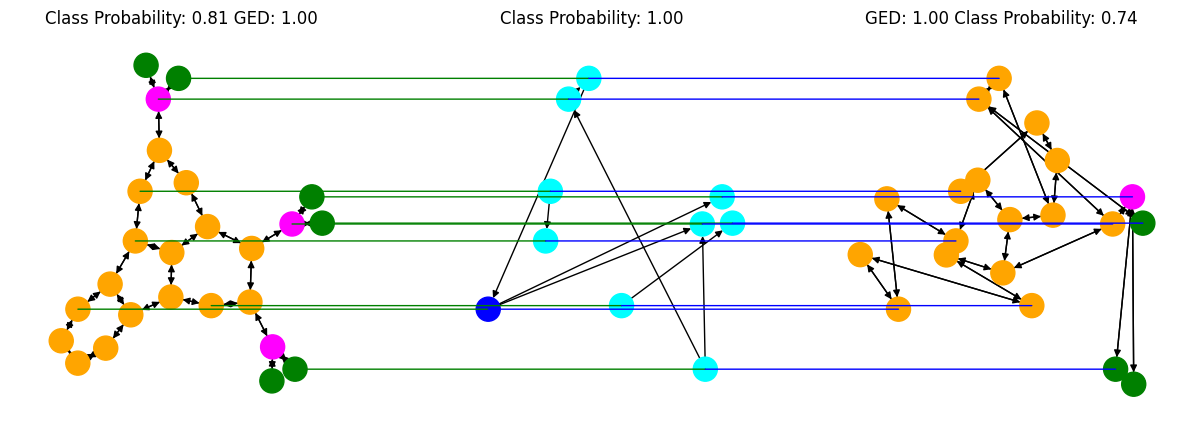

In [32]:
vis_con_graph(
    gen_gnnInt_1, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [23]:
gen_gnnInt_0 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8713, 0.8954)
Baseline % GED to 1
(0.0821, 0.0883)
Baseline % GED to 0
(0.0639, 0.0752)
Epoch: 0 Losses:[0.4247904230247844, -1.8480558828874067, 12843.299183238636, -2.7063671838153494]
Epoch: 1 Losses:[0.441915593364022, -1.840212886983698, 2039.1237127130682, -2.820454250682484]
Epoch: 2 Losses:[0.4086053181778301, -1.85999549518932, 679.1913785067471, -2.868814555081454]
Epoch: 3 Losses:[0.40498002008958295, -1.865991841663014, 264.7106642289595, -2.9098046151074497]
Epoch: 4 Losses:[0.38720363107594574, -1.8730974955992266, 111.45128562233664, -2.938943927938288]
Epoch: 5 Losses:[0.3882371024651961, -1.8780718066475608, 49.623390197753906, -2.901862534609708]
Epoch: 6 Losses:[0.4031667546792464, -1.8670367002487183, 23.39572351629084, -2.975438367236744]
Epoch: 7 Losses:[0.4116132909601385, -1.8580020666122437, 11.786694266579367, -2.976952411911704]
Epoch: 8 Losses:[0.4143443459814245, -1.8579390048980713, 6.581091360612349, -2.9448977275328203]


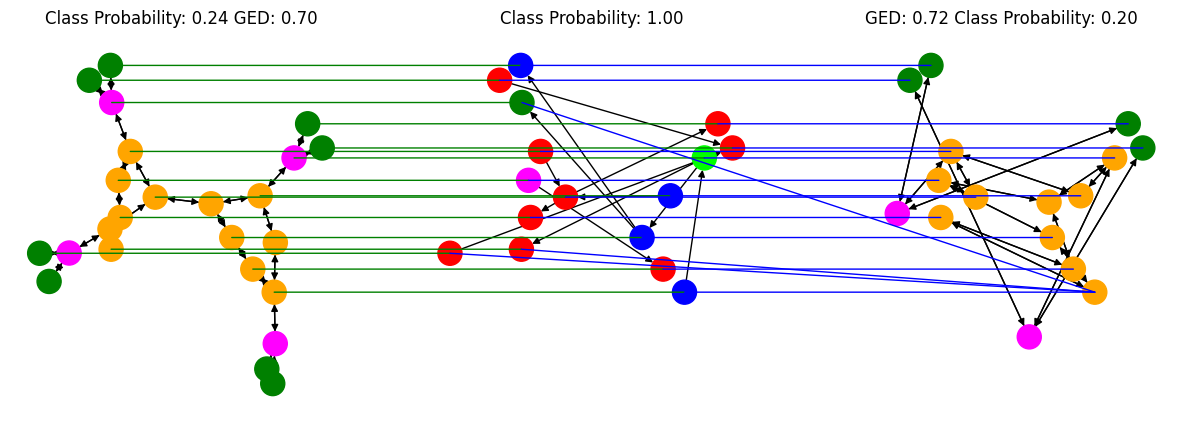

In [24]:
vis_con_graph(
    gen_gnnInt_0,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[2].clone(), 
    obs_ex2=test_data_list_0[3].clone(), 
    target=0
)

In [25]:
gen_gnnInt_1_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0129, 0.0181)
Baseline % GED to 1
(0.0796, 0.0849)
Baseline % GED to 0
(0.0613, 0.0704)
Epoch: 0 Losses:[3.0175611539320513, -0.08780327168377963, 12797.25106534091, 2.744410303505984]
Epoch: 1 Losses:[2.936628905209628, -0.09708810394460504, 2190.296875, 2.8402790264649824]
Epoch: 2 Losses:[3.071379618211226, -0.06439570405266502, 648.1366327459162, 2.9300770542838355]
Epoch: 3 Losses:[3.0695525732907383, -0.06621407819065181, 236.41784529252485, 2.995597330006686]
Epoch: 4 Losses:[3.1081525629216973, -0.05046678876334971, 97.46385817094283, 2.9653386852957984]
Epoch: 5 Losses:[3.118889331817627, -0.05014449425719001, 42.45570859042081, 2.9631870659914883]
Epoch: 6 Losses:[3.116283351724798, -0.049670972268689766, 19.530057907104492, 3.039208488030867]
Epoch: 7 Losses:[3.0995034087787974, -0.05517205595970154, 9.979841925881125, 2.921769759871743]
Epoch: 8 Losses:[3.1157148751345547, -0.051015312698754395, 5.83454569903287, 3.007558237422596]
Epoch: 9

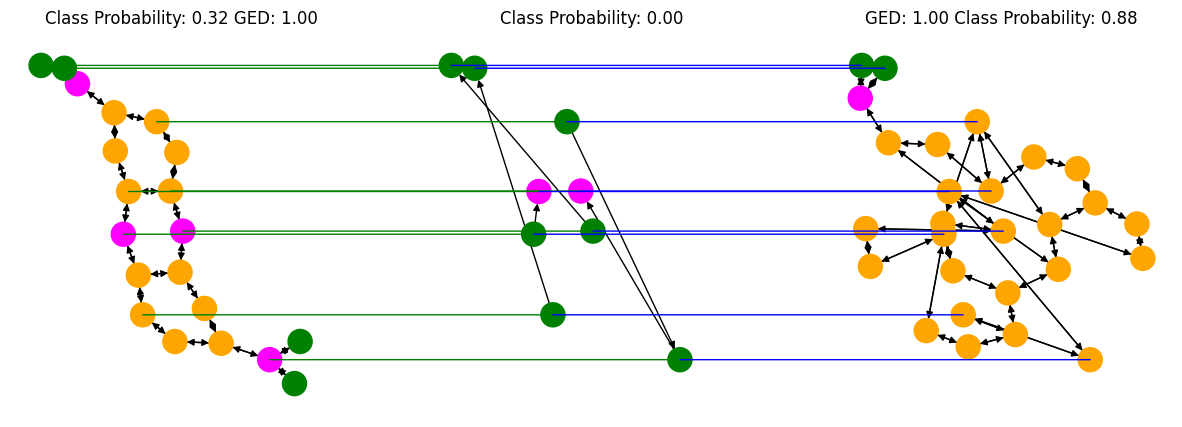

In [31]:
vis_con_graph(
    gen_gnnInt_1_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[1].clone(), 
    obs_ex2=test_data_list_dropped_1[5].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [27]:
gen_gnnInt_0_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9934, 0.9959)
Baseline % GED to 1
(0.0759, 0.0796)
Baseline % GED to 0
(0.0646, 0.0703)
Epoch: 0 Losses:[0.38911751725456933, -1.857487526806918, 11917.831853693182, -2.4538146149028432]
Epoch: 1 Losses:[0.3775087838823145, -1.8685158491134644, 2024.5123512961648, -2.643550677732988]
Epoch: 2 Losses:[0.37633917006579315, -1.8664510683579878, 654.2056857022372, -2.6996964162046257]
Epoch: 3 Losses:[0.37503003261306067, -1.8643645156513562, 251.3163396661932, -2.6793743697079746]
Epoch: 4 Losses:[0.3751704747026617, -1.8643461465835571, 105.56866524436258, -2.706440968946977]
Epoch: 5 Losses:[0.3745957748456435, -1.8620158542286267, 45.48205375671387, -2.6296377182006836]
Epoch: 6 Losses:[0.3738150027665225, -1.8598856817592273, 20.465584234757856, -2.645532792264765]
Epoch: 7 Losses:[0.3733736357905648, -1.8573622703552246, 10.071417375044389, -2.5658738288012417]
Epoch: 8 Losses:[0.3770637837323276, -1.8513839678330855, 5.654746922579679, -2.6025469628

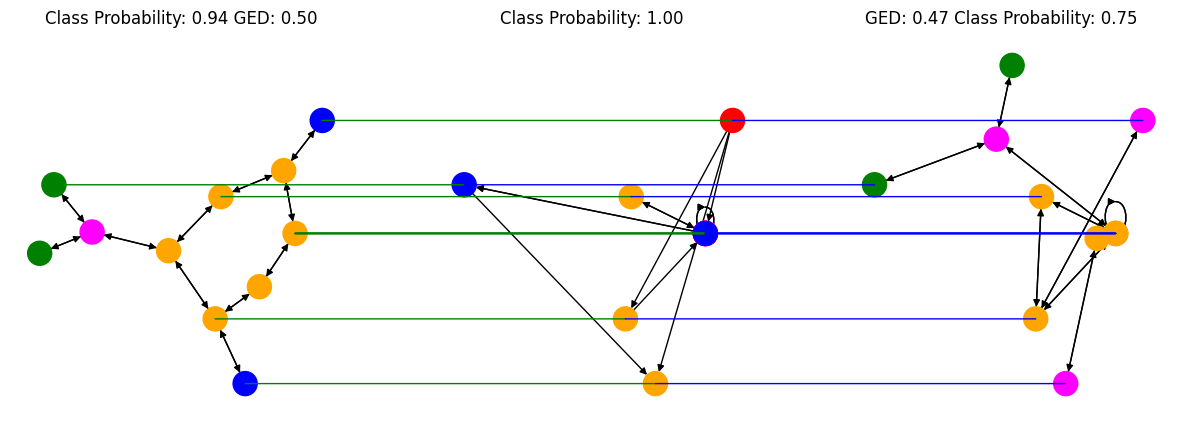

In [121]:
vis_con_graph(
    gen_gnnInt_0_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Multi-Layer Embedding Similarity

In [56]:
gen_gnnInt_1_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.036, 0.048)
Baseline % GED to 1
(0.08, 0.0842)
Baseline % GED to 0
(0.0628, 0.071)
Epoch: 0 Losses:[1.9370192614468662, -0.46998406743461435, 13818.62899502841, 2.620153161612424]
Epoch: 1 Losses:[1.444646878675981, -0.9561365084214644, 2380.3100807883525, 2.7415789474140513]
Epoch: 2 Losses:[1.166413133794611, -1.2950598760084673, 815.044170032848, 2.769443772055886]
Epoch: 3 Losses:[1.1438313072377986, -1.3412538766860962, 294.4731708873402, 2.7999795241789385]
Epoch: 4 Losses:[0.9510178945281289, -1.5339463624087246, 120.46809179132634, 2.8333547548814253]
Epoch: 5 Losses:[0.9262341694398359, -1.5892235799269243, 51.190519853071734, 2.8382568901235405]
Epoch: 6 Losses:[0.9052319526672363, -1.6422564333135432, 22.525533849542793, 2.9324429360303013]
Epoch: 7 Losses:[0.8560871807011691, -1.703277587890625, 10.7731331911954, 2.8527327234094795]
Epoch: 8 Losses:[0.8763608986681158, -1.677696629004045, 5.92850212617354, 2.926770979707891]
Epoch: 9 Losses

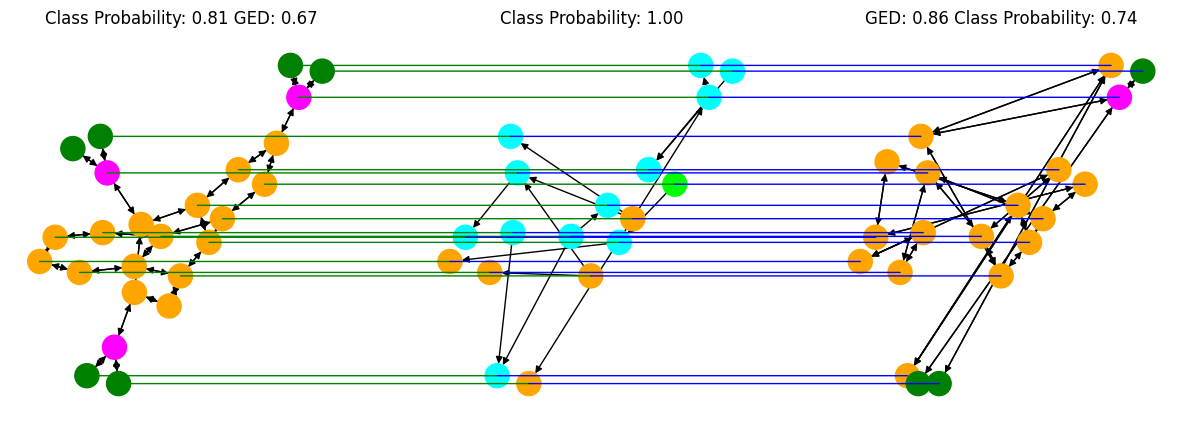

In [63]:
vis_con_graph(
    gen_gnnInt_1_ml, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [93]:
gen_gnnInt_0_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9735, 0.9819)
Baseline % GED to 1
(0.085, 0.0885)
Baseline % GED to 0
(0.0657, 0.0754)
Epoch: 0 Losses:[0.7110503099181436, -1.857246301390908, 12160.190296519886, -2.6341018460013648]
Epoch: 1 Losses:[0.667782799764113, -1.84732140194286, 1925.367098721591, -2.6793960495428606]
Epoch: 2 Losses:[0.6262333555655046, -1.8503850156610662, 606.1550903320312, -2.610022712837566]
Epoch: 3 Losses:[0.6000075123526833, -1.8456469232385808, 230.49196832830256, -2.5804572972384365]
Epoch: 4 Losses:[0.6337071061134338, -1.7838017398660833, 96.74405392733487, -2.6208966266025198]
Epoch: 5 Losses:[0.5988429297100414, -1.8045666759664363, 42.37756052884188, -2.4800142537463796]
Epoch: 6 Losses:[0.6224637952717867, -1.7382335662841797, 19.840368010781027, -2.501361841505224]
Epoch: 7 Losses:[0.6147424416108564, -1.7472479235042224, 10.02998872236772, -2.573191079226407]
Epoch: 8 Losses:[0.6007238138805736, -1.7780854268507524, 5.618763143366033, -2.5554357983849267]
E

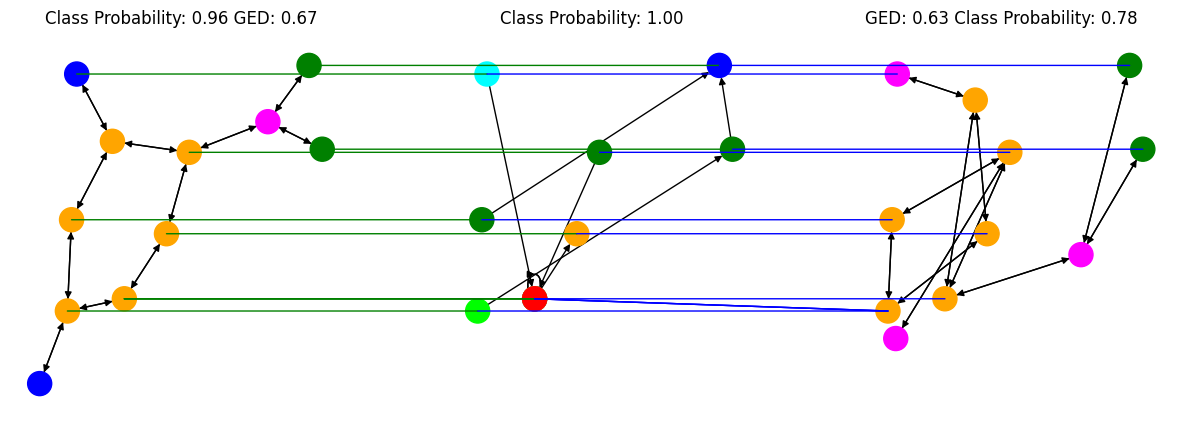

In [98]:
vis_con_graph(
    gen_gnnInt_0_ml,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [99]:
gen_gnnInt_1_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0006, 0.0019)
Baseline % GED to 1
(0.0856, 0.0909)
Baseline % GED to 0
(0.0661, 0.0751)
Epoch: 0 Losses:[2.384830344807018, -0.06168486279520122, 10881.068958629261, 2.5399771982973274]
Epoch: 1 Losses:[2.30880466374484, -0.05403537946668538, 1686.8365700461648, 2.579463091763583]
Epoch: 2 Losses:[2.1995040503415195, -0.05583512884649364, 513.1726878773082, 2.453905858776786]
Epoch: 3 Losses:[2.0866674835031684, -0.06106434389948845, 191.06858825683594, 2.3433403481136668]
Epoch: 4 Losses:[1.8290016000921077, -0.17244446311484685, 80.03415922685103, 2.3538589911027388]
Epoch: 5 Losses:[1.3928495537150989, -0.556741248477589, 36.06383462385698, 2.250438516790217]
Epoch: 6 Losses:[1.1058028069409458, -0.8499365178021517, 17.089031566273082, 2.2172323411161248]
Epoch: 7 Losses:[0.8954379179260947, -1.1222471865740689, 8.793469125574285, 2.1963026144287805]
Epoch: 8 Losses:[0.8578287688168612, -1.2103285139257258, 5.1726720116355205, 2.122602278536016]
Epo

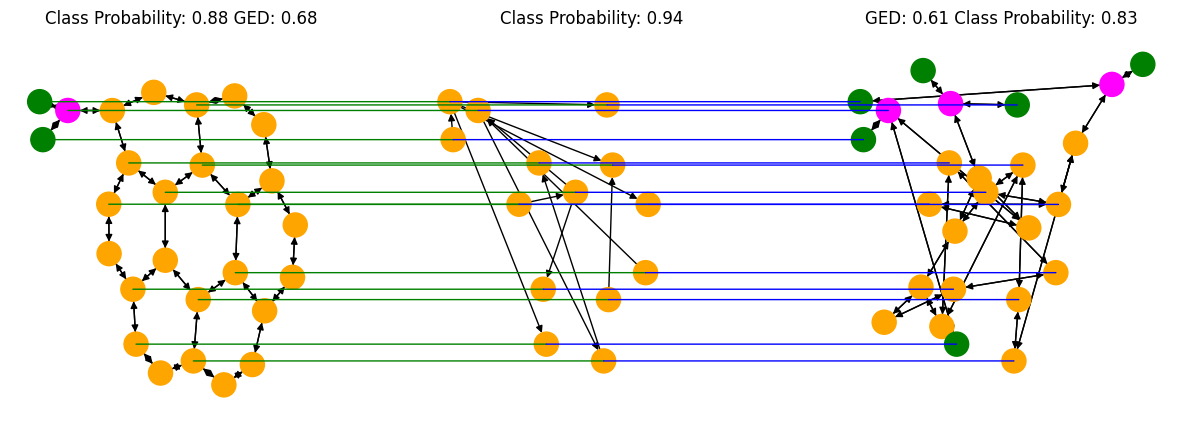

In [111]:
vis_con_graph(
    gen_gnnInt_1_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [112]:
gen_gnnInt_0_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9863, 0.9905)
Baseline % GED to 1
(0.0787, 0.0833)
Baseline % GED to 0
(0.0602, 0.0715)
Epoch: 0 Losses:[0.5888630585236982, -1.865255279974504, 12309.813587535511, -2.5410184318369087]
Epoch: 1 Losses:[0.5178525718775663, -1.859831539067355, 1929.1469671075995, -2.5321761911565606]
Epoch: 2 Losses:[0.4666032466021451, -1.845049099488692, 591.9667108709162, -2.4998848113146694]
Epoch: 3 Losses:[0.4638178185983138, -1.8171518824317239, 221.332255970348, -2.4887169870463284]
Epoch: 4 Losses:[0.4739642116156491, -1.8064807870171287, 91.83840768987483, -2.488676363771612]
Epoch: 5 Losses:[0.47897920554334467, -1.8149841265244917, 40.92147029529918, -2.5554076812484046]
Epoch: 6 Losses:[0.4848234247077595, -1.7943399602716619, 19.23899962685325, -2.508971013806083]
Epoch: 7 Losses:[0.49103840914639557, -1.7909273342652754, 9.888237086209385, -2.519422796639529]
Epoch: 8 Losses:[0.4950850145383315, -1.784515998580239, 5.69491923939098, -2.5763804479078813]
E

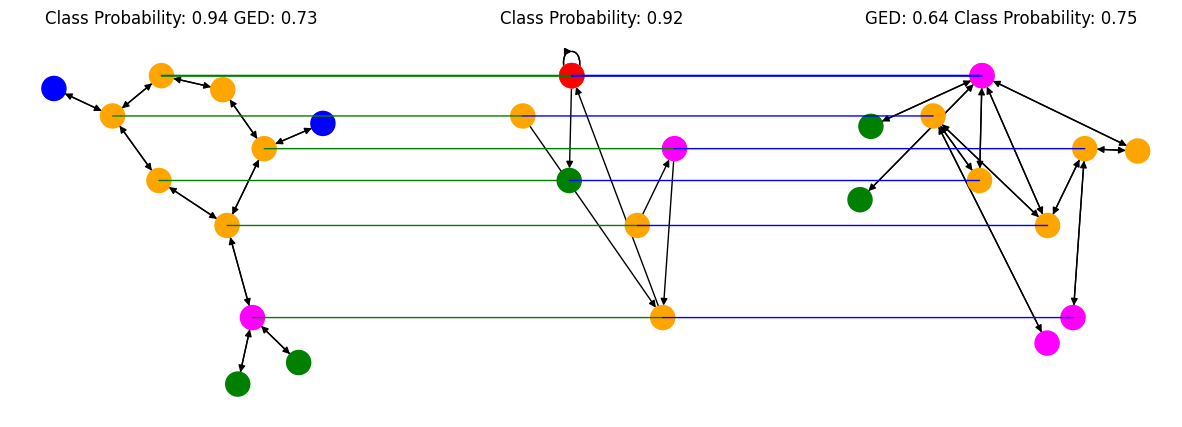

In [135]:
vis_con_graph(
    gen_gnnInt_0_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Opposing Class Embeddings

In [134]:
gen_gnnInt_1_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0175, 0.0259)
Baseline % GED to 1
(0.084, 0.0883)
Baseline % GED to 0
(0.0643, 0.0743)
Epoch: 0 Losses:[2.158392559398304, -0.45553080331195483, 12746.736194957386, 2.6421949104829268]
Epoch: 1 Losses:[1.6456668051806362, -0.656427648934451, 2210.695556640625, 2.758627707307989]
Epoch: 2 Losses:[1.5202799493616277, -0.7248049649325284, 768.1099243164062, 2.7685458551753652]
Epoch: 3 Losses:[1.322797580198808, -0.8270378112792969, 299.0623474121094, 2.8959876082160254]
Epoch: 4 Losses:[1.1543797308748418, -0.9182003086263483, 132.7880755337802, 2.8647353757511484]
Epoch: 5 Losses:[1.0118059353394941, -0.9750828526236794, 58.69336353648793, 2.894682840867476]
Epoch: 6 Losses:[0.949348585172133, -1.0207570682872424, 26.31867079301314, 2.8313525806773794]
Epoch: 7 Losses:[0.8611844723874872, -1.0889703956517307, 12.698738791725852, 2.918204578486356]
Epoch: 8 Losses:[0.871115039695393, -1.0859300331635908, 6.524689717726274, 2.8968007022684272]
Epoch: 9 Lo

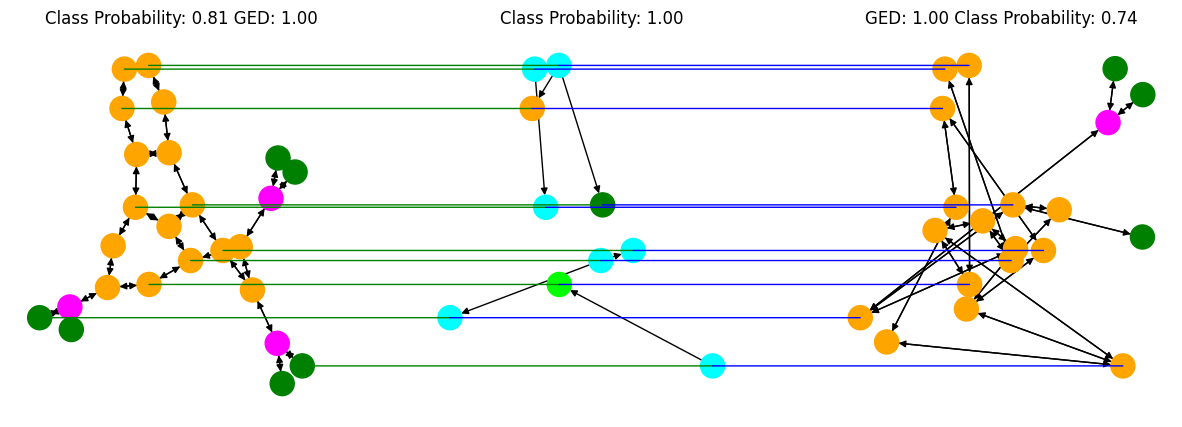

In [137]:
vis_con_graph(
    gen_gnnInt_1_oc, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [138]:
gen_gnnInt_0_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8856, 0.9043)
Baseline % GED to 1
(0.0808, 0.0868)
Baseline % GED to 0
(0.0669, 0.0756)
Epoch: 0 Losses:[0.7398794239217584, -1.155404036695307, 12098.865456321022, -2.5364768450910393]
Epoch: 1 Losses:[0.7517409974878485, -1.1694177931005305, 1790.9913884943182, -2.721134673465382]
Epoch: 2 Losses:[0.7629581960764799, -1.1820839643478394, 564.2948747114701, -2.753268539905548]
Epoch: 3 Losses:[0.7463518326932733, -1.1972360719333996, 216.47894564541903, -2.7890455939553003]
Epoch: 4 Losses:[0.7430573051626032, -1.1997581828724255, 89.44603035666726, -2.771475288000974]
Epoch: 5 Losses:[0.7696757533333518, -1.2058881629597058, 38.78888927806508, -2.803284601731734]
Epoch: 6 Losses:[0.7613168250430714, -1.2174696705558083, 17.882750597867098, -2.839773963798176]
Epoch: 7 Losses:[0.7617469917644154, -1.226774194023826, 8.871013728055088, -2.846895001151345]
Epoch: 8 Losses:[0.7667603655294939, -1.2111103317954324, 5.040388800881126, -2.8611484440890225]


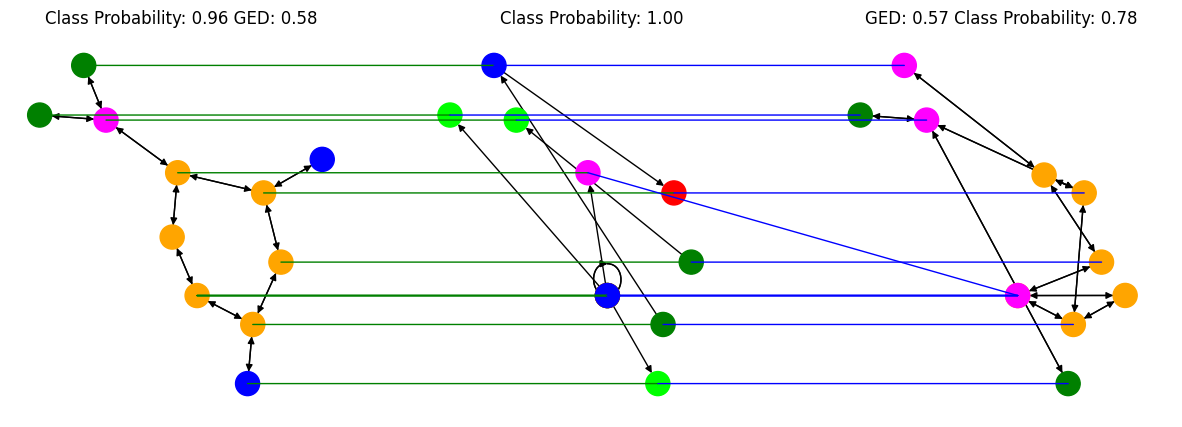

In [144]:
vis_con_graph(
    gen_gnnInt_0_oc,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [145]:
gen_gnnInt_1_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0011, 0.0019)
Baseline % GED to 1
(0.0796, 0.0835)
Baseline % GED to 0
(0.0641, 0.0745)
Epoch: 0 Losses:[2.37394211509011, -0.2572328651493246, 12194.837113813921, 2.4533984715288337]
Epoch: 1 Losses:[2.236039811914617, -0.17081551389260727, 2035.0736749822443, 2.427606837315993]
Epoch: 2 Losses:[1.9480786648663608, -0.1480422778563066, 642.0613209117543, 2.190964698791504]
Epoch: 3 Losses:[1.5925460620359941, -0.25516915185885, 257.8055225719105, 2.1398509578271345]
Epoch: 4 Losses:[1.1390191912651062, -0.46156758069992065, 121.55180220170455, 2.1955406719988044]
Epoch: 5 Losses:[0.8968667387962341, -0.6377229500900615, 55.911925922740586, 2.118963073600422]
Epoch: 6 Losses:[0.8306010636416349, -0.6985761306502603, 24.70712765780362, 2.0995715748180044]
Epoch: 7 Losses:[0.7669835036451166, -0.7426410967653448, 11.844815861095082, 2.0961260253732856]
Epoch: 8 Losses:[0.70105534250086, -0.7921400937167081, 6.45490061153065, 2.1235926422205837]
Epoch: 9 

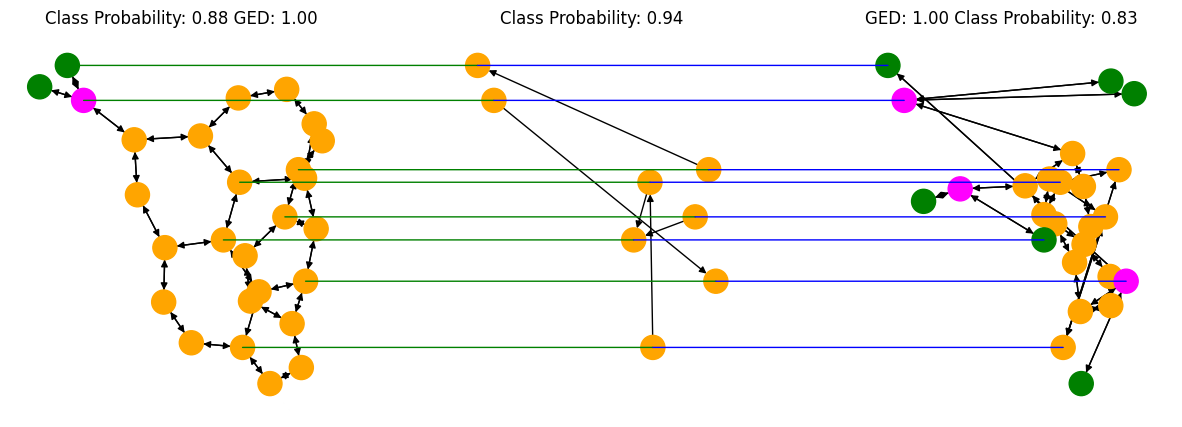

In [149]:
vis_con_graph(
    gen_gnnInt_1_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [150]:
gen_gnnInt_0_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9972, 0.9986)
Baseline % GED to 1
(0.0804, 0.0839)
Baseline % GED to 0
(0.0641, 0.0731)
Epoch: 0 Losses:[0.6464589400724932, -1.1540041294964878, 11832.282870205965, -2.6386018991470337]
Epoch: 1 Losses:[0.6515467817133124, -1.1644099950790405, 1896.929570978338, -2.7566398924047295]
Epoch: 2 Losses:[0.6478752818974581, -1.162049109285528, 580.9760520241477, -2.853892293843356]
Epoch: 3 Losses:[0.6523648175326261, -1.1688505411148071, 216.6826310591264, -2.9200090278278696]
Epoch: 4 Losses:[0.6443440805781971, -1.1596872806549072, 87.62714940851384, -2.874190926551819]
Epoch: 5 Losses:[0.6489957625215704, -1.1661959453062578, 38.519494316794656, -3.023398215120489]
Epoch: 6 Losses:[0.6512930176474832, -1.1684615828774192, 18.116803429343484, -3.0127507773312656]
Epoch: 7 Losses:[0.650878830389543, -1.1677440404891968, 9.279271385886453, -3.0165427164597944]
Epoch: 8 Losses:[0.6522497805682096, -1.1674499945207075, 5.410099896517667, -3.026983152736317]

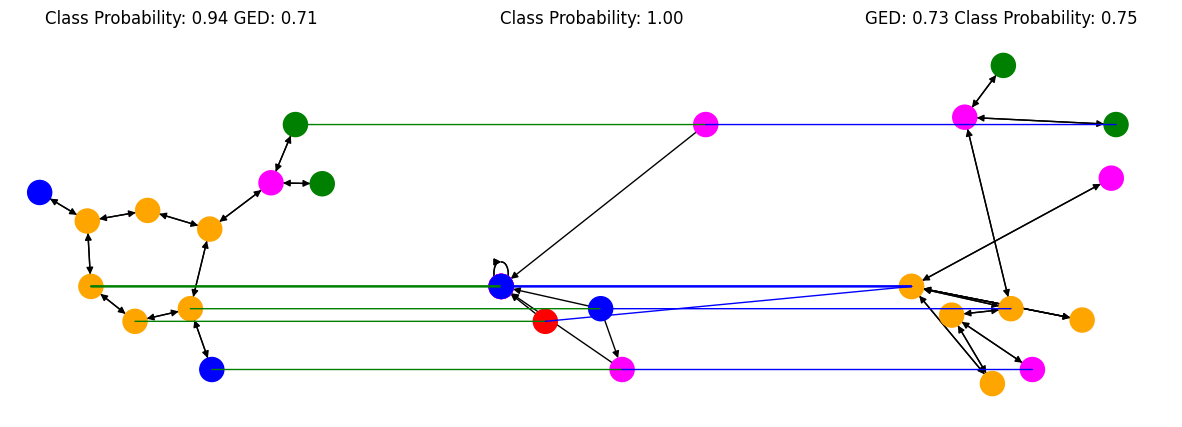

In [157]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Only GED

In [179]:
gen_gnnInt_1_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.164, 0.1941)
Baseline % GED to 1
(0.0837, 0.0877)
Baseline % GED to 0
(0.0658, 0.0768)
Epoch: 0 Losses:[1.928695028478449, -0.3581018772992221, 13903.88583096591, 2.4579292264851658]
Epoch: 1 Losses:[1.7398162213238804, -0.31904981759461487, 2925.552334872159, 2.2928022633899343]
Epoch: 2 Losses:[1.671218915419145, -0.26788274672898377, 1351.9318181818182, 2.068557089025324]
Epoch: 3 Losses:[1.590942144393921, -0.2622033113783056, 836.2223399769176, 1.849962521683086]
Epoch: 4 Losses:[1.3698989152908325, -0.3293090042742816, 569.0171813964844, 1.7514587749134412]
Epoch: 5 Losses:[1.2296009172092786, -0.37425764853304083, 432.28611061789775, 1.6113217093727805]
Epoch: 6 Losses:[1.1155229915272107, -0.42561213536696, 350.5462840687145, 1.5022461305965076]
Epoch: 7 Losses:[1.095780540596355, -0.42928738214752893, 295.944618918679, 1.43992741541429]
Epoch: 8 Losses:[0.993740206415003, -0.48461818965998565, 254.33434919877485, 1.3691306764429265]
Epoch: 9 L

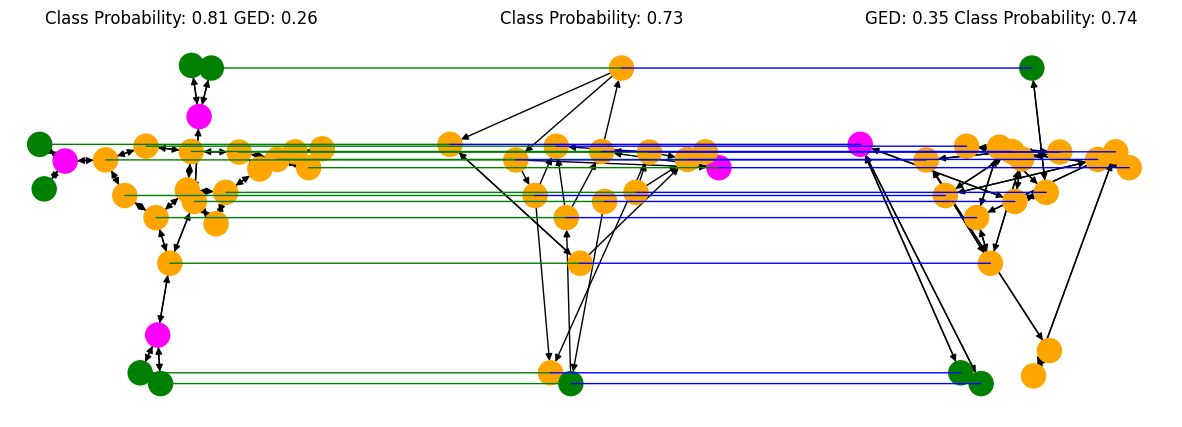

In [183]:
vis_con_graph(
    gen_gnnInt_1_GED, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [195]:
gen_gnnInt_0_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-6, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9309, 0.9472)
Baseline % GED to 1
(0.0871, 0.09)
Baseline % GED to 0
(0.067, 0.0782)
Epoch: 0 Losses:[0.8605569980361245, -1.0303758545355364, 16284.271218039772, -2.7211754376238044]
Epoch: 1 Losses:[0.8230779441920194, -1.0611996108835393, 7043.682972301136, -2.820522904396057]
Epoch: 2 Losses:[0.9031390385194258, -1.0355960889296099, 4585.467551491477, -2.912054950540716]
Epoch: 3 Losses:[0.8630938584154303, -1.0659821304407986, 3230.1336780894885, -2.848729198629206]
Epoch: 4 Losses:[0.8843678886240179, -1.0808093656193127, 2303.3671542080965, -2.9254596450112085]
Epoch: 5 Losses:[0.7921517870642922, -1.1215534752065486, 1673.3029452237215, -2.916239543394609]
Epoch: 6 Losses:[0.7919045849279924, -1.1123178872195156, 1255.5478293678977, -2.9371633638035166]
Epoch: 7 Losses:[0.8058493895964189, -1.1245802532542835, 917.4614202325994, -2.8953109004280786]
Epoch: 8 Losses:[0.815492803400213, -1.1065721728584983, 723.0362881747159, -2.9481045224449853]

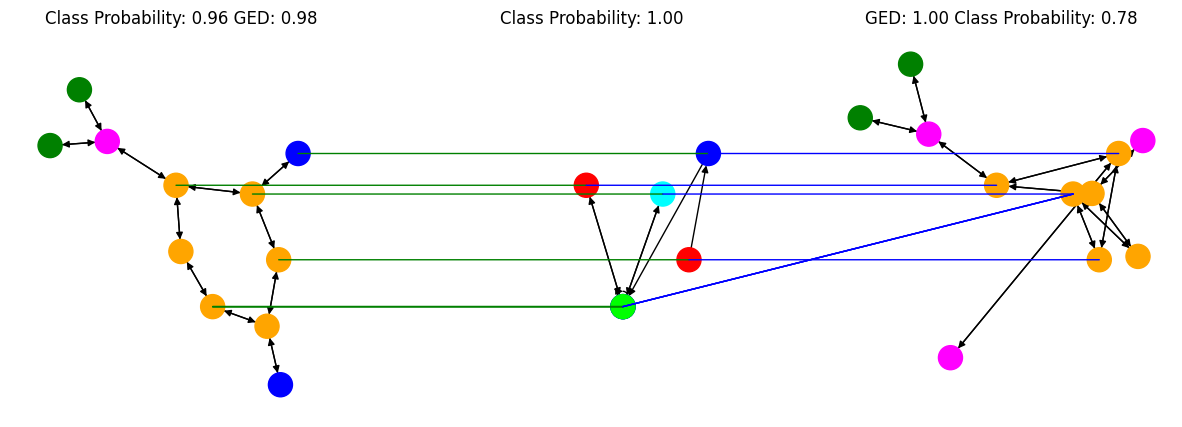

In [204]:
vis_con_graph(
    gen_gnnInt_0_GED,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [208]:
gen_gnnInt_1_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.0309, 0.0394)
Baseline % GED to 1
(0.076, 0.0797)
Baseline % GED to 0
(0.0586, 0.0698)
Epoch: 0 Losses:[2.3152563138441606, -0.23753675276582892, 12694.692072088068, 2.216825842857361]
Epoch: 1 Losses:[2.249017932198264, -0.1730298548936844, 2880.6624755859375, 1.9551122947172686]
Epoch: 2 Losses:[2.1232117956334893, -0.11597245051102205, 1377.9960493607955, 1.7707079323855313]
Epoch: 3 Losses:[1.9849198081276633, -0.1241552701050585, 788.2529629794034, 1.6530977325005964]
Epoch: 4 Losses:[1.8865287520668723, -0.1305235495621508, 542.2136785333806, 1.5586972345005383]
Epoch: 5 Losses:[1.7872371781956067, -0.14193795485930008, 424.6070584383878, 1.406474844975905]
Epoch: 6 Losses:[1.582704414020885, -0.2363712110302665, 333.89779385653407, 1.4017886140129783]
Epoch: 7 Losses:[1.4565857973965732, -0.29345366087826813, 285.15788130326706, 1.3582484071904963]
Epoch: 8 Losses:[1.3378326567736538, -0.34893454340371216, 244.90735418146306, 1.306294479153373]


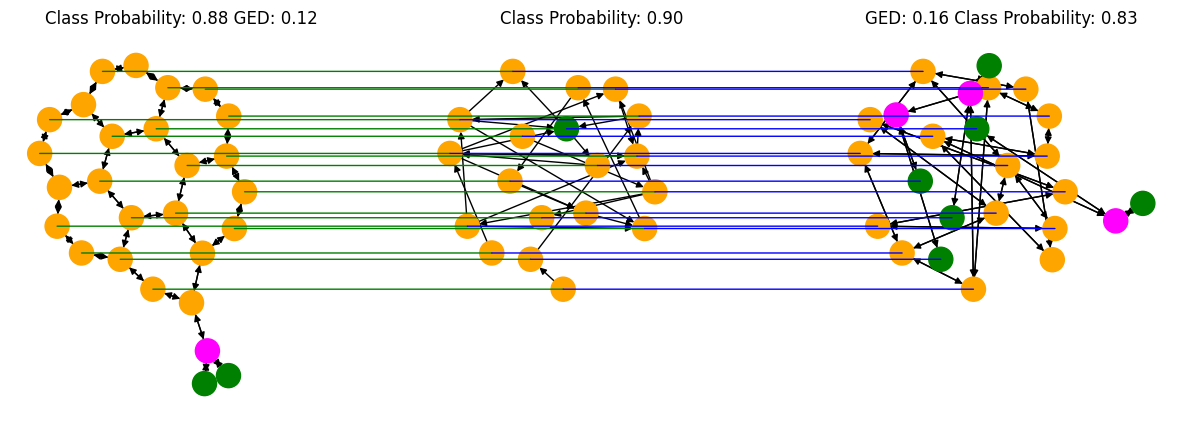

In [220]:
vis_con_graph(
    gen_gnnInt_1_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [221]:
gen_gnnInt_0_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-6, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9834, 0.9897)
Baseline % GED to 1
(0.0732, 0.0764)
Baseline % GED to 0
(0.0594, 0.0703)
Epoch: 0 Losses:[0.6207027218558572, -1.1234761476516724, 17191.129350142044, -2.6474640369415283]
Epoch: 1 Losses:[0.6407451683824713, -1.152421474456787, 7917.986683238636, -2.827719813043421]
Epoch: 2 Losses:[0.6527212804014032, -1.1646767963062634, 5144.467063210227, -2.911417310888117]
Epoch: 3 Losses:[0.6560465259985491, -1.1686986901543357, 3591.156582919034, -3.0585070198232476]
Epoch: 4 Losses:[0.6639356125484813, -1.1749793182719837, 2524.110262784091, -3.0778237256136807]
Epoch: 5 Losses:[0.6714558438821272, -1.1816526543010364, 1893.4772838245738, -3.121781262484464]
Epoch: 6 Losses:[0.6786573204127225, -1.1881430799310857, 1477.7177734375, -3.1403678438880225]
Epoch: 7 Losses:[0.6771985021504489, -1.1869683265686035, 1077.1210660067472, -3.1233948577534068]
Epoch: 8 Losses:[0.6842053207484159, -1.1923098130659624, 789.5870638760654, -3.11316454410553]
E

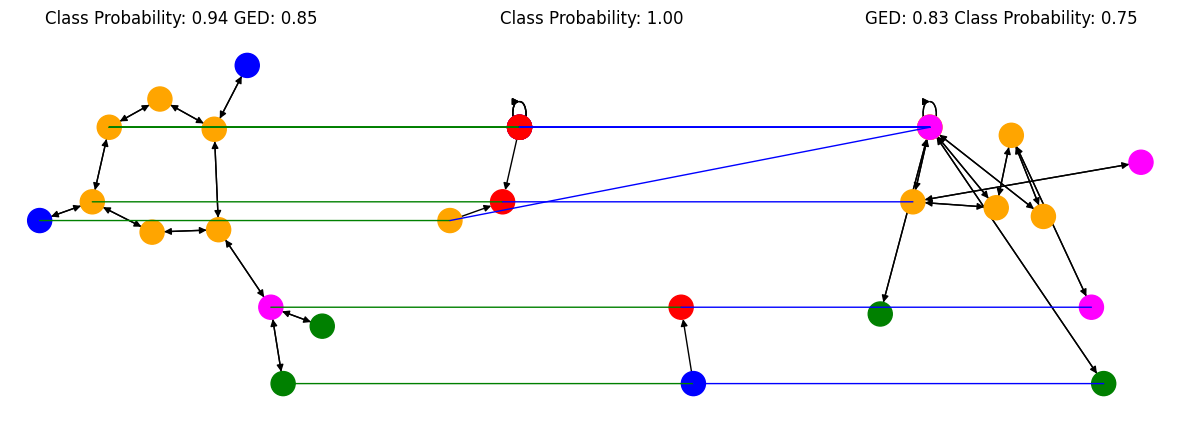

In [229]:
vis_con_graph(
    gen_gnnInt_0_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Full Loss

In [452]:
gen_gnnInt_1_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1e-3]), 
)

Baseline Prediction Accuracy: 
(0.1798, 0.2138)
Baseline % GED to 1
(0.0753, 0.0788)
Baseline % GED to 0
(0.0609, 0.0717)
Epoch: 0 Losses:[1.4681743925268, -0.6379064158959822, 11984.657958984375, 2.2707355401732703]
Epoch: 1 Losses:[1.0254684361544522, -0.8867175741629167, 1494.185663396662, 2.255516691641374]
Epoch: 2 Losses:[0.9887470548803156, -0.9552622654221274, 385.33273037997157, 2.2260394421490757]
Epoch: 3 Losses:[0.8650280833244324, -1.0419249209490689, 111.98358258334073, 2.196782274679704]
Epoch: 4 Losses:[0.8464996327053417, -1.0690040263262661, 33.835730812766336, 2.1183415217833086]
Epoch: 5 Losses:[0.8101041967218573, -1.1002805883234197, 11.956571839072488, 2.207816392183304]
Epoch: 6 Losses:[0.8401153466918252, -1.084581190889532, 5.356393077156761, 2.1672212264754553]
Epoch: 7 Losses:[0.7849167910489169, -1.1324226747859607, 3.233695246956565, 2.180818021297455]
Epoch: 8 Losses:[0.8107387260957197, -1.1234635385600003, 2.3759327801791104, 2.1876079602675005]
Epoch: 

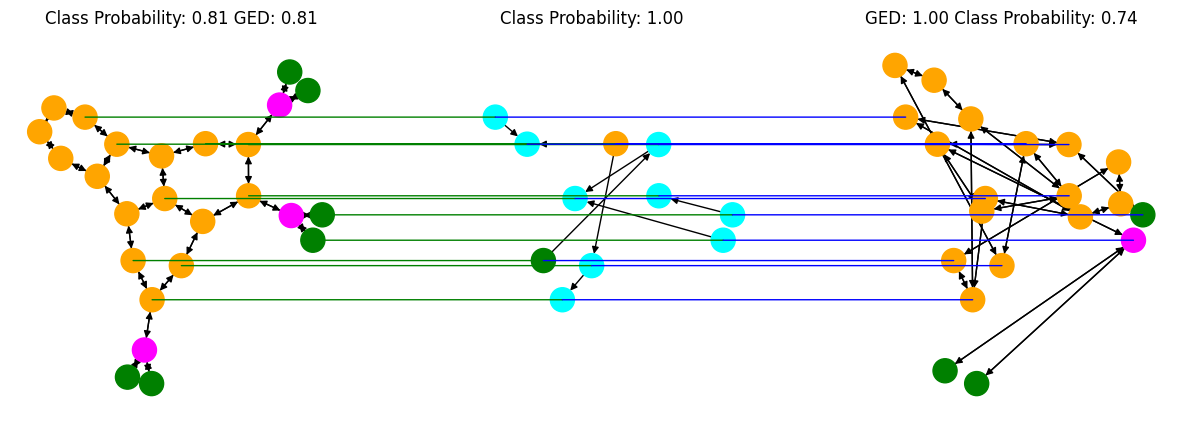

In [455]:
vis_con_graph(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [258]:
gen_gnnInt_0_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-7, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9198, 0.9399)
Baseline % GED to 1
(0.0868, 0.0924)
Baseline % GED to 0
(0.0695, 0.0785)
Epoch: 0 Losses:[0.7445385510271246, -1.1636294559998945, 16584.38556463068, -2.752587676048279]
Epoch: 1 Losses:[0.7613344463435087, -1.2066532915288752, 8159.298561789773, -2.8692855509844692]
Epoch: 2 Losses:[0.7538496960293163, -1.22531550580805, 5523.543235085227, -2.890669335018505]
Epoch: 3 Losses:[0.7627987536517057, -1.2337055206298828, 4257.674937855114, -2.8976901336149736]
Epoch: 4 Losses:[0.768412936817516, -1.2330074418674817, 3281.8893821022725, -2.9134796315973457]
Epoch: 5 Losses:[0.7776764739643444, -1.2359005646272139, 2372.6796653053975, -2.951660080389543]
Epoch: 6 Losses:[0.7807767607948997, -1.2403740774501453, 1862.518954190341, -2.930880318988453]
Epoch: 7 Losses:[0.7734005180272189, -1.246141878041354, 1480.2970636541193, -2.9121103286743164]
Epoch: 8 Losses:[0.7760148590261285, -1.2464278177781538, 1141.9131081321023, -2.9119067842310127]


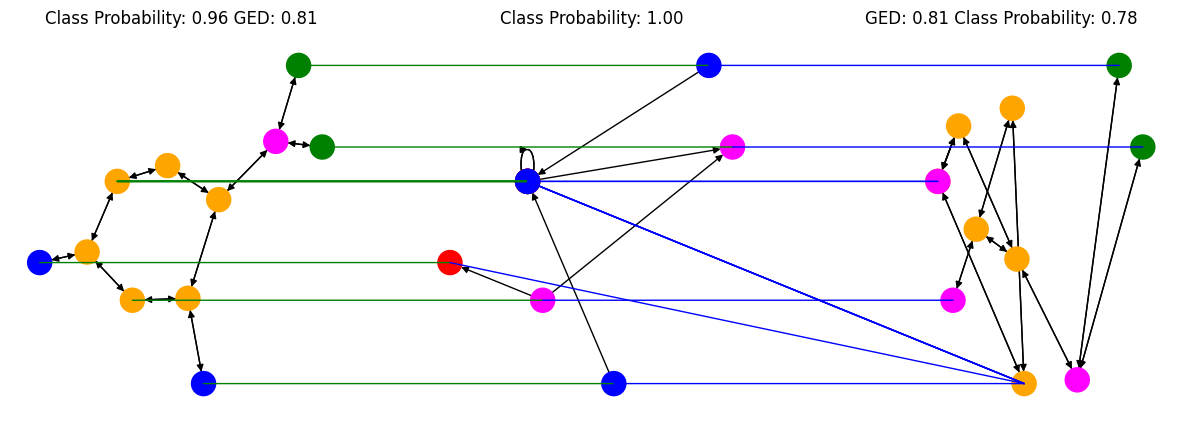

In [260]:
vis_con_graph(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [367]:
gen_gnnInt_1_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.1, 0.1, 1e-4, 1.0]), 
    epochs=25
)

Baseline Prediction Accuracy: 
(0.0009, 0.0014)
Baseline % GED to 1
(0.0791, 0.0841)
Baseline % GED to 0
(0.06, 0.0705)
Epoch: 0 Losses:[2.353748820044778, -0.23905090445821936, 12868.004927201704, 2.3581495772708547]
Epoch: 1 Losses:[2.2512821934439917, -0.17608937892046841, 3006.4157492897725, 2.098116636276245]
Epoch: 2 Losses:[2.1392033750360664, -0.1354005275802179, 1333.1490700461648, 1.9239195693622937]
Epoch: 3 Losses:[1.9916707710786299, -0.15012347427281467, 749.1464344371449, 1.7220501412044873]
Epoch: 4 Losses:[1.8319477059624412, -0.19446383890780536, 503.2684881036932, 1.6133898279883645]
Epoch: 5 Losses:[1.7504199526526711, -0.19593336162242023, 354.37962480024856, 1.5023915063251148]
Epoch: 6 Losses:[1.5245229656046086, -0.29755170914259826, 300.3597939231179, 1.4305794401602312]
Epoch: 7 Losses:[1.277132424441251, -0.4206086586822163, 258.86014903675425, 1.3317965431646868]
Epoch: 8 Losses:[1.1564731489528308, -0.4857672263275493, 239.3749209317294, 1.3349771770563992]

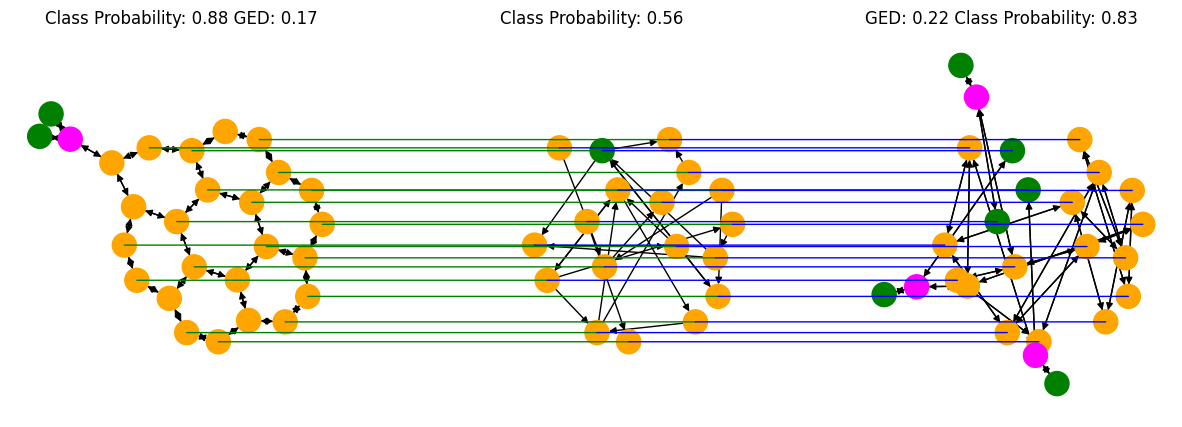

In [373]:
vis_con_graph(
    gen_gnnInt_1_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

### Clean-UP

In [29]:
import gc

# Get all objects in the current context
for obj in gc.get_objects():
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Clear the cache
torch.cuda.empty_cache()

# Optionally synchronize (wait for GPU computations to finish)
torch.cuda.synchronize()

/work/DPDS/s224833/Dissertation/gnn-egg/env/egg-env-38/lib/python3.8/site-packages/torch/distributed/distributed_c10d.py:293: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  warnings.warn(
